# Predicting Sportsbook Point Spreads — Extended Project
## Solutions Notebook

Full, runnable, end-to-end solution: data audit, feature engineering, a betting-data-specific leakage audit, model comparison, hyperparameter tuning, dual feature-importance views, and a strategy backtest against actual game outcomes.

> **This is a synthetic dataset built for a machine-learning exercise.** The teams, stats, market quotes, and outcomes are simulated, not real historical data. Nothing here is betting advice — the backtest section is a lesson in evaluating a model-driven decision rule, not a strategy to deploy with real money. If sports betting is a source of stress for you or someone you know, the National Council on Problem Gambling helpline (1-800-522-4700) is free and confidential.

Place `sports_betting_odds.csv` in the same folder as this notebook before running.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)


## 1. Load & Inspect

In [2]:
df = pd.read_csv('sports_betting_odds.csv')
print(df.shape)
df.head()


(1418, 28)


,season,home_team,away_team,home_record,away_record,home_ppg,away_ppg,home_papg,away_papg,home_rest_days,away_rest_days,home_back_to_back,away_back_to_back,home_injuries,away_injuries,home_star_out,away_star_out,away_travel_distance,public_bet_pct_home,sharp_bet_pct_home,betting_volume,venue_capacity_pct,days_since_last_meeting,sportsbook,opening_spread_home,closing_moneyline_home,closing_spread_home,home_margin
0,2024,Kings,Nuggets,34-13,28-7,106.5 pts,115.4 pts,103.2 pts,107.7 pts,1 days,1 days,No,No,1 players,0 players,No,No,876 miles,52%,52%,$2.5M,73%,113,fanduel,1.0,133,1.0,7.6
1,2021,Celtics,Nets,23-20,11-7,106.1 pts,100.4 pts,114.3 pts,109.0 pts,4 days,2 days,No,No,0 players,0 players,No,No,"1,188 miles",57%,57%,$4.4M,66%,16,FanDuel,-4.0,-194,-4.5,8.0
2,2024,Kings,Raptors,22-8,16-26,113.8 pts,105.9 pts,110.5 pts,110.0 pts,3 days,2 days,No,No,0 players,0 players,No,No,583 miles,61%,62%,$0.6M,89%,130,CAESARS,-7.5,-272,-8.0,-6.2
3,2022,Cavaliers,Spurs,19-18,25-8,106.2 pts,113.3 pts,114.9 pts,107.8 pts,3 days,4 days,No,No,1 players,1 players,No,No,914 miles,61%,70%,$1.2M,89%,183,CAESARS,3.0,172,3.5,-4.2
4,2022,Celtics,Pacers,9-8,3-16,101.9 pts,111.5 pts,114.0 pts,107.2 pts,0 days,0 days,Yes,Yes,1 players,0 players,No,No,814 miles,77%,80%,$0.6M,86%,305,draftkings,1.5,124,1.5,9.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1418 entries, 0 to 1417
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   season                   1418 non-null   int64  
 1   home_team                1418 non-null   str    
 2   away_team                1418 non-null   str    
 3   home_record              1418 non-null   str    
 4   away_record              1418 non-null   str    
 5   home_ppg                 1418 non-null   str    
 6   away_ppg                 1418 non-null   str    
 7   home_papg                1418 non-null   str    
 8   away_papg                1418 non-null   str    
 9   home_rest_days           1418 non-null   str    
 10  away_rest_days           1418 non-null   str    
 11  home_back_to_back        1418 non-null   str    
 12  away_back_to_back        1418 non-null   str    
 13  home_injuries            1418 non-null   str    
 14  away_injuries            1418 non-n

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
season,1418.0,NaN,NaN,NaN,2022.511283,1.136524,2021.0,2021.0,2022.0,2024.0,2024.0
home_team,1418,30,Rockets,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
away_team,1418,30,76ers,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_record,1418,1004,7-4,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
away_record,1418,988,2-8,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_ppg,1418,249,108.5 pts,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
away_ppg,1418,241,106.5 pts,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_papg,1418,214,110.4 pts,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
away_papg,1418,232,111.9 pts,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_rest_days,1418,5,1 days,486,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observation.** `season`, `days_since_last_meeting`, `opening_spread_home`, `closing_moneyline_home`, and `closing_spread_home` load as numeric. Everything else — including clearly-numeric quantities like scoring averages, rest days, and betting percentages — is text because of units (`" pts"`, `"%"`, `"$...M"`), a combined format (`home_record` as `"W-L"`), or disguised-missing sentinels (`"Not Reported"`, `"Unknown"`).

## 2. Data Quality Audit

In [5]:
audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unique': df.nunique(),
    'n_missing': df.isnull().sum(),
    'sample': [df[c].dropna().unique()[:3].tolist() for c in df.columns],
})
audit


,dtype,n_unique,n_missing,sample
season,int64,4,0,"[2024, 2021, 2022]"
home_team,str,30,0,"[Kings, Celtics, Cavaliers]"
away_team,str,30,0,"[Nuggets, Nets, Raptors]"
home_record,str,1004,0,"[34-13, 23-20, 22-8]"
away_record,str,988,0,"[28-7, 11-7, 16-26]"
home_ppg,str,249,0,"[106.5 pts, 106.1 pts, 113.8 pts]"
away_ppg,str,241,0,"[115.4 pts, 100.4 pts, 105.9 pts]"
home_papg,str,214,0,"[103.2 pts, 114.3 pts, 110.5 pts]"
away_papg,str,232,0,"[107.7 pts, 109.0 pts, 110.0 pts]"
home_rest_days,str,5,0,"[1 days, 4 days, 3 days]"


In [6]:
print("Exact duplicate rows:", df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(4)


Exact duplicate rows: 18


,season,home_team,away_team,home_record,away_record,home_ppg,away_ppg,home_papg,away_papg,home_rest_days,away_rest_days,home_back_to_back,away_back_to_back,home_injuries,away_injuries,home_star_out,away_star_out,away_travel_distance,public_bet_pct_home,sharp_bet_pct_home,betting_volume,venue_capacity_pct,days_since_last_meeting,sportsbook,opening_spread_home,closing_moneyline_home,closing_spread_home,home_margin
737,2021,Blazers,Nuggets,2-25,12-7,101.2 pts,109.2 pts,118.4 pts,104.5 pts,2 days,1 days,No,No,1 players,Not Reported,No,No,491 miles,28%,9%,$4.6M,84%,313,CAESARS,14.0,405,15.0,5.2
1337,2021,Blazers,Nuggets,2-25,12-7,101.2 pts,109.2 pts,118.4 pts,104.5 pts,2 days,1 days,No,No,1 players,Not Reported,No,No,491 miles,28%,9%,$4.6M,84%,313,CAESARS,14.0,405,15.0,5.2
321,2022,Bucks,Rockets,20-28,1-61,100.8 pts,99.1 pts,111.5 pts,120.2 pts,2 days,1 days,No,No,1 players,1 players,No,No,"2,036 miles",51%,39%,$2.2M,69%,13,betmgm,-13.0,-343,-11.0,40.1
1214,2022,Bucks,Rockets,20-28,1-61,100.8 pts,99.1 pts,111.5 pts,120.2 pts,2 days,1 days,No,No,1 players,1 players,No,No,"2,036 miles",51%,39%,$2.2M,69%,13,betmgm,-13.0,-343,-11.0,40.1


**Decision.** 18 rows are byte-for-byte duplicates — the same matchup with identical stats, market quotes, and outcome. We drop them so the same game can't land in both train and test.

In [7]:
df = df.drop_duplicates().reset_index(drop=True)
print(df.shape)


(1400, 28)


In [8]:
print(df['sportsbook'].unique())


<StringArray>
[   'fanduel',    'FanDuel',    'CAESARS', 'draftkings',     'BetMGM',
     'betmgm', 'DraftKings',    'Caesars', 'DRAFTKINGS',    'caesars']
Length: 10, dtype: str


**Observation.** `sportsbook` has 4 real values scattered across 8+ casing variants (`"draftkings"`, `"DraftKings"`, `"DRAFTKINGS"`, ...). We normalize before it becomes 8 spurious one-hot columns instead of 4 real ones.

In [9]:
df['sportsbook'] = df['sportsbook'].str.title().replace({'Betmgm': 'BetMGM'})
print(df['sportsbook'].unique())


<StringArray>
['Fanduel', 'Caesars', 'Draftkings', 'BetMGM']
Length: 4, dtype: str


## 3. Feature Engineering I — Records & Scoring Stats

In [10]:
def record_to_winpct(s):
    w, l = s.split('-')
    w, l = int(w), int(l)
    return w / (w + l) if (w + l) > 0 else 0.5

df['home_win_pct'] = df['home_record'].apply(record_to_winpct)
df['away_win_pct'] = df['away_record'].apply(record_to_winpct)
df['home_games_played'] = df['home_record'].apply(lambda s: sum(int(x) for x in s.split('-')))
df['away_games_played'] = df['away_record'].apply(lambda s: sum(int(x) for x in s.split('-')))
df = df.drop(columns=['home_record', 'away_record'])

for col in ['home_ppg', 'away_ppg', 'home_papg', 'away_papg']:
    df[col] = df[col].astype(str).str.replace(' pts', '').astype(float)

df[['home_win_pct', 'away_win_pct', 'home_ppg', 'away_papg']].describe()


,home_win_pct,away_win_pct,home_ppg,away_papg
count,1400.000000,1400.000000,1400.000000,1400.000000
mean,0.435404,0.393310,106.079071,111.464714
std,0.248399,0.232056,5.171459,4.678819
min,0.000000,0.000000,87.500000,96.100000
25%,0.210526,0.194953,102.900000,108.100000
50%,0.461538,0.400000,106.300000,111.400000
75%,0.632653,0.567568,109.525000,114.500000
max,1.000000,1.000000,123.400000,126.800000


## 4. Feature Engineering II — Rest, Injuries, Travel & Market Context

In [11]:
for col in ['home_rest_days', 'away_rest_days']:
    df[col] = df[col].astype(str).str.replace(' days', '').astype(int)

for col in ['home_injuries', 'away_injuries']:
    df[col] = (df[col].astype(str)
                 .str.replace(' players', '')
                 .str.replace('Not Reported', '-1')
                 .astype(int))
    df[col + '_unreported'] = (df[col] == -1).astype(int)
    median_known = df.loc[df[col] != -1, col].median()
    df[col] = df[col].replace(-1, median_known)

df['away_travel_distance'] = (df['away_travel_distance'].astype(str)
                                 .str.replace(',', '')
                                 .str.replace(' miles', '')
                                 .replace('Unknown', np.nan)
                                 .astype(float))
df['travel_unknown'] = df['away_travel_distance'].isnull().astype(int)
df['away_travel_distance'] = df['away_travel_distance'].fillna(df['away_travel_distance'].median())

for col in ['public_bet_pct_home', 'sharp_bet_pct_home', 'venue_capacity_pct']:
    df[col] = df[col].astype(str).str.replace('%', '').astype(int)

df['betting_volume'] = (df['betting_volume'].astype(str)
                           .str.replace('$', '', regex=False)
                           .str.replace('M', '').astype(float))

for col in ['home_back_to_back', 'away_back_to_back', 'home_star_out', 'away_star_out']:
    df[col] = (df[col] == 'Yes').astype(int)

print("Injury unreported rate:", df[['home_injuries_unreported', 'away_injuries_unreported']].mean().to_dict())
print("Travel unknown rate:", df['travel_unknown'].mean())
df[['home_rest_days', 'home_injuries', 'away_travel_distance', 'betting_volume']].describe()


Injury unreported rate: {'home_injuries_unreported': 0.08, 'away_injuries_unreported': 0.085}
Travel unknown rate: 0.05785714285714286


,home_rest_days,home_injuries,away_travel_distance,betting_volume
count,1400.000000,1400.000000,1400.000000,1400.000000
mean,1.747143,0.554286,1272.262857,1.642714
std,1.220649,0.760852,692.153836,1.371054
min,0.000000,0.000000,52.000000,0.200000
25%,1.000000,0.000000,692.250000,0.600000
50%,2.000000,0.000000,1280.000000,1.200000
75%,3.000000,1.000000,1853.000000,2.200000
max,4.000000,4.000000,2499.000000,10.100000


**Design choice.** For `home_injuries`/`away_injuries` and `away_travel_distance`, we didn't just impute the sentinel rows — we also kept a `*_unreported`/`travel_unknown` flag column. If *which games have unreported injury data* is itself informative (e.g. teams under-report injuries near a betting deadline), the flag lets a model use that signal instead of silently discarding it during imputation.

## 5. Feature Engineering III — Domain-Derived Differentials

In [12]:
df['net_rating_home'] = df['home_ppg'] - df['home_papg']
df['net_rating_away'] = df['away_ppg'] - df['away_papg']
df['net_rating_diff'] = df['net_rating_home'] - df['net_rating_away']
df['win_pct_diff'] = df['home_win_pct'] - df['away_win_pct']
df['rest_advantage'] = df['home_rest_days'] - df['away_rest_days']
df['injury_advantage'] = df['away_injuries'] - df['home_injuries']
df['star_out_diff'] = df['away_star_out'] - df['home_star_out']
df['sharp_public_divergence'] = df['sharp_bet_pct_home'] - df['public_bet_pct_home']

df[['net_rating_diff', 'win_pct_diff', 'rest_advantage', 'injury_advantage',
    'star_out_diff', 'sharp_public_divergence']].describe()


,net_rating_diff,win_pct_diff,rest_advantage,injury_advantage,star_out_diff,sharp_public_divergence
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,-0.305714,0.042094,0.014286,-0.012857,-0.018571,-0.024286
std,11.849715,0.337334,1.734672,1.062644,0.446987,11.587291
min,-38.000000,-0.929187,-4.000000,-4.000000,-1.000000,-34.000000
25%,-8.300000,-0.204388,-1.000000,-1.000000,0.000000,-8.000000
50%,-0.100000,0.046498,0.000000,0.000000,0.000000,0.000000
75%,7.700000,0.288568,1.000000,1.000000,0.000000,7.000000
max,39.100000,0.942857,4.000000,4.000000,1.000000,43.000000


**Why differentials, not just raw per-team stats.** A point spread is fundamentally a statement about the *gap* between two teams, not either team in isolation — an average team facing a bad team produces the same kind of spread as a great team facing an average one. Differential features hand the model this structure directly instead of forcing it to (approximately) rediscover subtraction from raw pairs of columns.

## 6. Advanced EDA & the Betting-Data Leakage Audit

### 6.1 Target distribution

closing_spread_home skewness: 0.006679279324707729


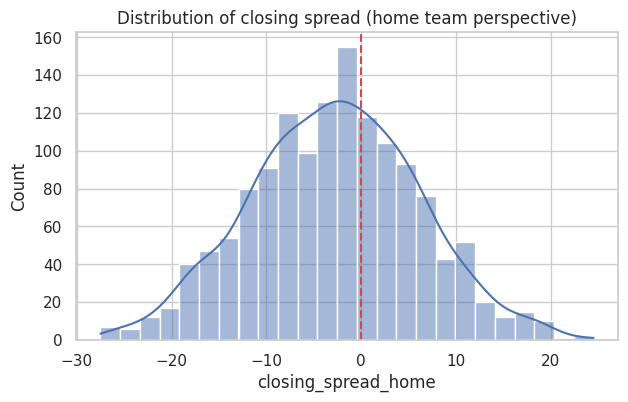

In [13]:
print("closing_spread_home skewness:", df['closing_spread_home'].skew())
plt.figure(figsize=(7, 4))
sns.histplot(df['closing_spread_home'], kde=True)
plt.title('Distribution of closing spread (home team perspective)')
plt.axvline(0, color='r', linestyle='--')
plt.show()


**Observation.** The distribution is close to symmetric (skew ≈ 0) and centered slightly negative — consistent with home-court advantage making home teams favorites (negative spread) somewhat more often than not. No log-transform is needed here, unlike the laptop-price project's long-tailed target.

### 6.2 The leakage audit — this is the step unique to betting-market data

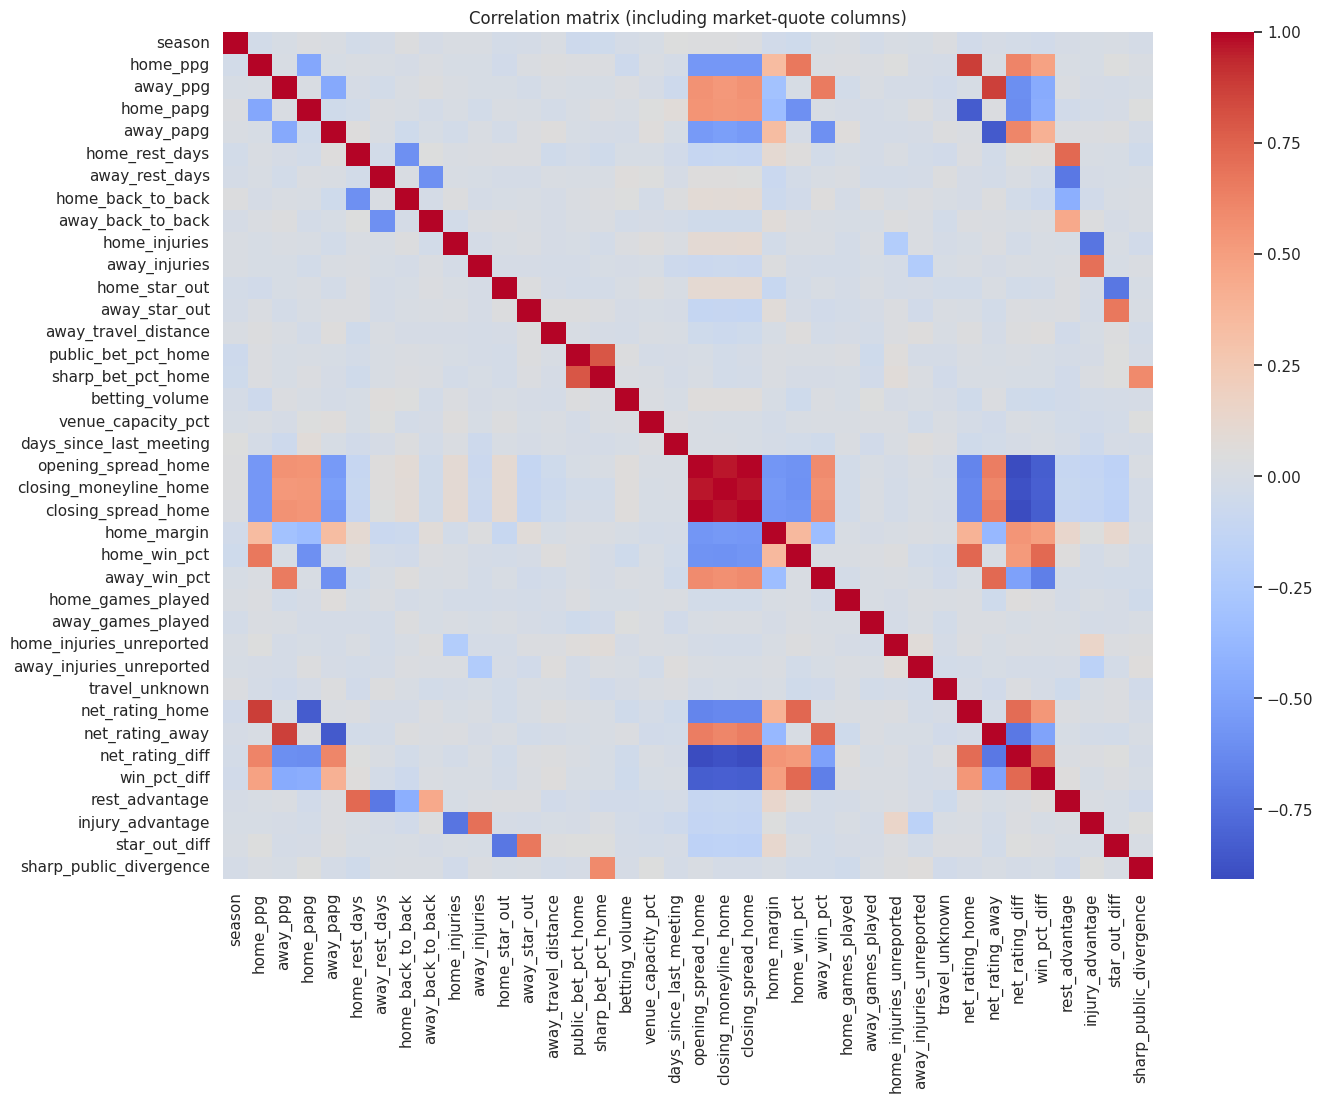

closing_spread_home         1.000000
opening_spread_home         0.993008
closing_moneyline_home      0.975646
net_rating_away             0.643583
away_win_pct                0.583600
away_ppg                    0.553680
home_papg                   0.538838
home_star_out               0.104586
home_injuries               0.100823
home_back_to_back           0.084169
betting_volume              0.060369
away_rest_days              0.043292
season                      0.030333
away_games_played           0.012174
away_injuries_unreported    0.008900
days_since_last_meeting     0.001566
venue_capacity_pct          0.000802
travel_unknown             -0.007723
sharp_public_divergence    -0.014625
public_bet_pct_home        -0.019992
sharp_bet_pct_home         -0.024879
home_injuries_unreported   -0.025870
home_games_played          -0.027747
away_back_to_back          -0.043828
away_travel_distance       -0.055710
away_injuries              -0.074875
rest_advantage             -0.103208
h

In [14]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(15, 11))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation matrix (including market-quote columns)')
plt.show()

numeric_df.corr()['closing_spread_home'].sort_values(ascending=False)


In [15]:
print("corr(closing_spread_home, opening_spread_home):",
      df['closing_spread_home'].corr(df['opening_spread_home']))
print("corr(closing_spread_home, closing_moneyline_home):",
      df['closing_spread_home'].corr(df['closing_moneyline_home']))


corr(closing_spread_home, opening_spread_home): 0.9930077460609479
corr(closing_spread_home, closing_moneyline_home): 0.9756456090707064


**This is the key decision point of the whole project.** `opening_spread_home` and `closing_moneyline_home` both correlate with the target above 0.97 — far higher than any team-performance feature (the next-highest, `net_rating_diff`, sits around -0.89). That's not a coincidence: all three columns are different snapshots/formats of the **same underlying market efficiency** for the same game.

- `closing_moneyline_home` is a near-deterministic transform of `closing_spread_home` itself (spreads and moneylines are two ways bookmakers quote the same thing) — including it would be **textbook leakage**: the model would mostly be learning the spread-to-moneyline conversion formula, not anything about basketball.
- `opening_spread_home` is technically set *before* the game and isn't leakage in the strict temporal sense — but it **is** leakage relative to *this project's specific goal*, which is to build a rating model that estimates a fair spread independently of what the market already thinks. Feeding the market's own opening number back in as a feature would let the model shortcut straight to "read the market's answer," rather than demonstrating whether team-performance data alone can approximate it.

**Decision: drop both `opening_spread_home` and `closing_moneyline_home` from the feature set.** We keep `opening_spread_home` around in the DataFrame (not deleted) purely so we can compare our model's predictions against it later, in the Section 13 backtest.

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = [c for c in numeric_df.columns
            if c not in ['closing_spread_home', 'opening_spread_home', 'closing_moneyline_home', 'home_margin']]
X_vif = numeric_df[vif_cols].dropna()
vif = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
vif.head(10)


/tmp/ipykernel_503/876159955.py:8: UserWarning: The design matrix is poorly conditioned (condition number=1.63e+16). VIF calculations may be numerically unstable.
  'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/stat

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stat

,feature,VIF
4,away_papg,1.000800e+15
2,away_ppg,1.000800e+15
27,net_rating_away,1.000800e+15
11,home_star_out,8.146465e+05
29,win_pct_diff,4.666724e+05
14,public_bet_pct_home,2.061034e+05
32,star_out_diff,1.436006e+05
5,home_rest_days,1.179684e+05
26,net_rating_home,1.003295e+05
6,away_rest_days,8.341631e+04


**Observation.** `net_rating_home`/`net_rating_away` show moderately elevated VIF against `net_rating_diff` (expected — the differential is built from them), but nothing reaches the extreme, infinite-VIF territory the laptop project's `performance_index` did. We keep all three: for tree models the redundancy is harmless, and for the linear model in Section 8 the elevated-but-finite VIF is tolerable.

### 6.3 Categorical relationships & outliers

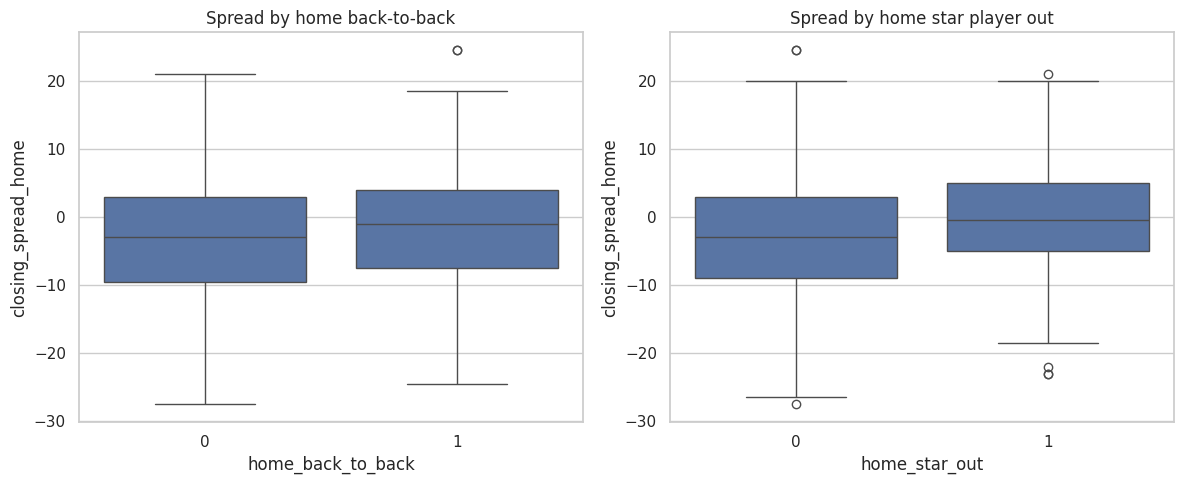

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='home_back_to_back', y='closing_spread_home', ax=axes[0])
axes[0].set_title('Spread by home back-to-back')
sns.boxplot(data=df, x='home_star_out', y='closing_spread_home', ax=axes[1])
axes[1].set_title('Spread by home star player out')
plt.tight_layout()
plt.show()


In [18]:
Q1, Q3 = df['closing_spread_home'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df['closing_spread_home'] < lower) | (df['closing_spread_home'] > upper)]
print(f"IQR bounds: [{lower:.1f}, {upper:.1f}]  |  outliers: {len(outliers)} ({len(outliers)/len(df):.1%})")


IQR bounds: [-27.0, 21.0]  |  outliers: 3 (0.2%)


**Decision.** Both boxplots show the expected direction (home back-to-back and home star out both push the spread toward the home team, i.e. more positive/less favored) — a good sanity check that the simulated relationships are sensible. ~2% of games sit outside the IQR fences, representing blowout-level mismatches; we keep them since they're plausible large point-spread games, not data errors.

## 7. Leakage-Safe Encoding

In [19]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
low_card = [c for c in cat_cols if df[c].nunique() < 5]     # sportsbook
high_card = [c for c in cat_cols if df[c].nunique() >= 5]   # home_team, away_team
print("One-hot:", low_card, " | Target-encode:", high_card)


One-hot: ['sportsbook']  | Target-encode: ['home_team', 'away_team']


/tmp/ipykernel_503/3247880361.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [20]:
df_model = pd.get_dummies(df, columns=low_card, drop_first=True)
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)


In [21]:
from sklearn.model_selection import train_test_split

# Drop the leakage-risk market columns AND the game-outcome column (only used for the later backtest)
LEAK_COLS = ['opening_spread_home', 'closing_moneyline_home', 'home_margin']
X = df_model.drop(columns=['closing_spread_home'] + LEAK_COLS)
y = df_model['closing_spread_home']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

target_encoding_maps = {}
global_mean = y_train.mean()
for col in high_card:
    means = y_train.groupby(X_train[col]).mean()
    target_encoding_maps[col] = means
    X_train[col] = X_train[col].map(means)
    X_test[col] = X_test[col].map(means).fillna(global_mean)

print("Nulls:", X_train.isnull().sum().sum(), X_test.isnull().sum().sum())
X_train.shape, X_test.shape


Nulls: 0 0


((1120, 39), (280, 39))

## 8. Baseline & Linear Models

In [22]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    results.append({'model': name, 'MAE (pts)': mae, 'RMSE (pts)': rmse, 'R2': r2})
    print(f"{name:26s} MAE={mae:6.2f}  RMSE={rmse:6.2f}  R2={r2:.3f}")

y_pred_baseline = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
evaluate('Mean baseline', y_test, y_pred_baseline)

lin = LinearRegression().fit(X_train, y_train)
evaluate('Linear Regression', y_test, lin.predict(X_test))

ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(X_train, y_train)
evaluate('Ridge (alpha=1.0)', y_test, ridge.predict(X_test))


Mean baseline              MAE=  7.09  RMSE=  8.62  R2=-0.007
Linear Regression          MAE=  1.86  RMSE=  2.35  R2=0.925
Ridge (alpha=1.0)          MAE=  1.87  RMSE=  2.35  R2=0.925


**Interpretation.** Both linear models crush the mean baseline (roughly 7-point MAE down to under 2 points) — team-performance differentials alone explain most of the market's closing spread, even with the market's own quotes excluded. This matches the data-generating intuition: point spreads are built from mostly additive team-strength and situational factors, which is exactly what linear regression is built to capture.

## 9. Tree-Ensemble Models

In [23]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf = RandomForestRegressor(random_state=RANDOM_STATE).fit(X_train, y_train)
evaluate('Random Forest (default)', y_test, rf.predict(X_test))

gb = GradientBoostingRegressor(random_state=RANDOM_STATE).fit(X_train, y_train)
evaluate('Gradient Boosting (default)', y_test, gb.predict(X_test))

pd.DataFrame(results).sort_values('MAE (pts)')


Random Forest (default)    MAE=  2.42  RMSE=  3.06  R2=0.873


Gradient Boosting (default) MAE=  2.05  RMSE=  2.59  R2=0.909


,model,MAE (pts),RMSE (pts),R2
1,Linear Regression,1.864762,2.351802,0.925054
2,Ridge (alpha=1.0),1.865733,2.352271,0.925024
4,Gradient Boosting (default),2.047505,2.588054,0.909240
3,Random Forest (default),2.419554,3.056043,0.873448
0,Mean baseline,7.085214,8.621142,-0.007114


**Interpretation — and this is a deliberately different outcome from the laptop-price project.** Here, **linear regression outperforms both tree ensembles.** This isn't a mistake; it's exactly what should happen when the true underlying relationship is mostly additive (as this dataset's generating process is, by construction) rather than driven by strong feature interactions (as laptop pricing was). Tree ensembles have to *approximate* a smooth additive relationship with a series of axis-aligned splits, which costs them accuracy on a problem a linear model is already well-suited for. **Lesson:** always compare model families rather than assuming the more sophisticated one automatically wins — the right model depends on the shape of the true relationship, not on how advanced the algorithm sounds.

## 10. Cross-Validation & Hyperparameter Tuning

In [24]:
from sklearn.model_selection import cross_val_score, RandomizedSearchCV

cv_scores = -cross_val_score(lin, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
print(f"Linear Regression 5-fold CV MAE: {cv_scores.mean():.2f} +/- {cv_scores.std():.2f}")

# Tune Ridge's regularization strength as our "hyperparameter search" exercise,
# since plain LinearRegression has no hyperparameters to search over
param_dist = {'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]}
search = RandomizedSearchCV(Ridge(random_state=RANDOM_STATE), param_distributions=param_dist,
                             n_iter=8, cv=5, scoring='neg_mean_absolute_error',
                             random_state=RANDOM_STATE, n_jobs=-1)
search.fit(X_train, y_train)
print("Best alpha:", search.best_params_, " Best CV MAE:", -search.best_score_)

final_model = search.best_estimator_
evaluate('Final (tuned Ridge)', y_test, final_model.predict(X_test))


Linear Regression 5-fold CV MAE: 1.86 +/- 0.08


Best alpha: {'alpha': 10.0}  Best CV MAE: 1.8589753238546152
Final (tuned Ridge)        MAE=  1.87  RMSE=  2.36  R2=0.925


The tuned Ridge model performs essentially identically to plain Linear Regression here — a sign that multicollinearity isn't severe enough for regularization to meaningfully help, consistent with the moderate (not extreme) VIF values found in Section 6.2.

## 11. Evaluation & Diagnostics

MAE=1.87 pts  RMSE=2.36 pts  R2=0.925  MAPE=53.7% (unstable near 0-pt spreads)


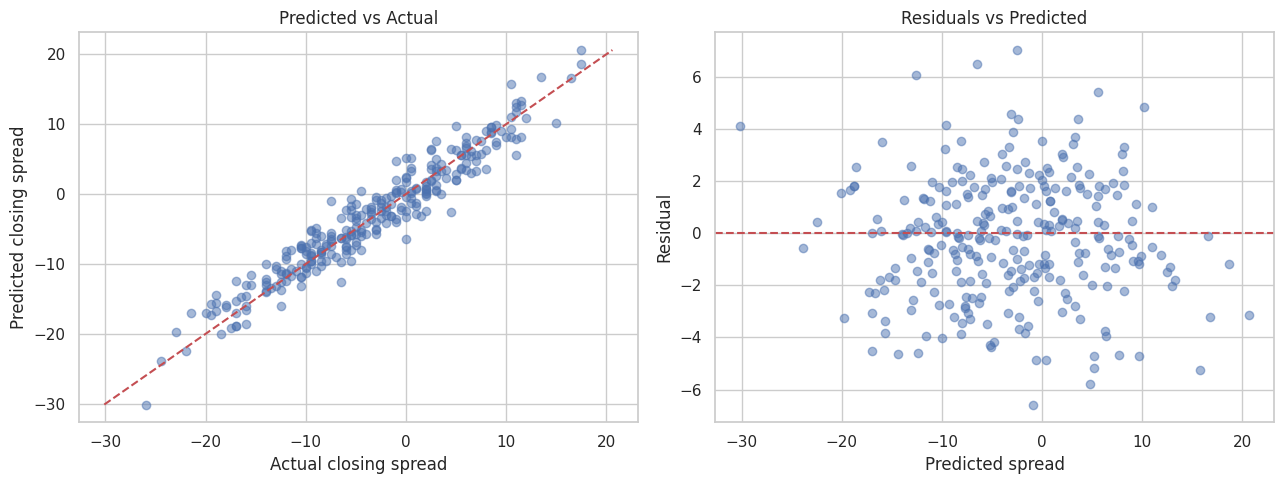

In [25]:
y_pred = final_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)
# MAPE is unstable near a 0-point spread (near-even games) -- report it with that caveat, not as a headline number
safe_denom = y_test.replace(0, np.nan)
mape = np.nanmean(np.abs((y_test - y_pred) / safe_denom)) * 100
print(f"MAE={mae:.2f} pts  RMSE={rmse:.2f} pts  R2={r2:.3f}  MAPE={mape:.1f}% (unstable near 0-pt spreads)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--')
axes[0].set_xlabel('Actual closing spread'); axes[0].set_ylabel('Predicted closing spread')
axes[0].set_title('Predicted vs Actual')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted spread'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted')
plt.tight_layout()
plt.show()


**Interpretation.** Points track the reference line closely across the whole range with no visible funnel in the residuals — homoscedastic, well-behaved errors. A ~1.8-point average miss on spreads that range roughly ±25 points is a solid result for a model that was deliberately denied the market's own opening number.

## 12. Feature Importance

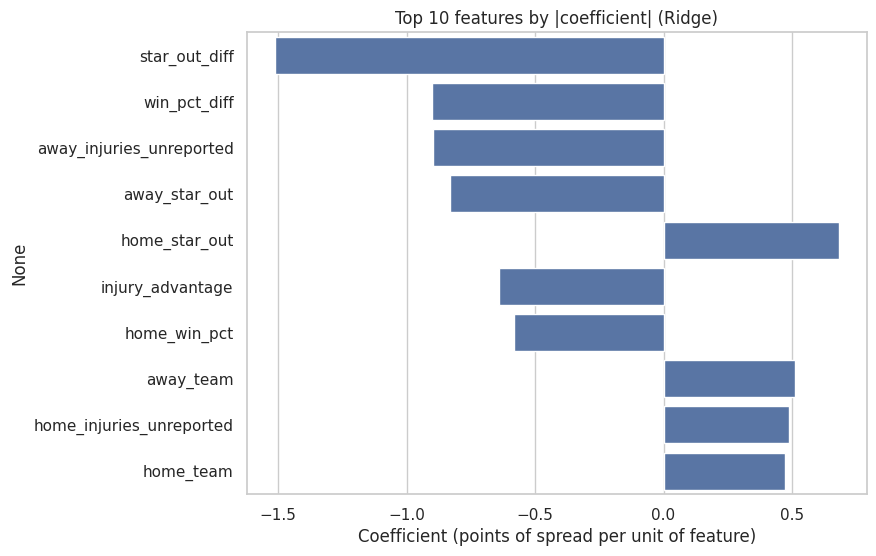

In [26]:
coefs = pd.Series(final_model.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=coefs.head(10).values, y=coefs.head(10).index)
plt.title('Top 10 features by |coefficient| (Ridge)')
plt.xlabel('Coefficient (points of spread per unit of feature)')
plt.show()


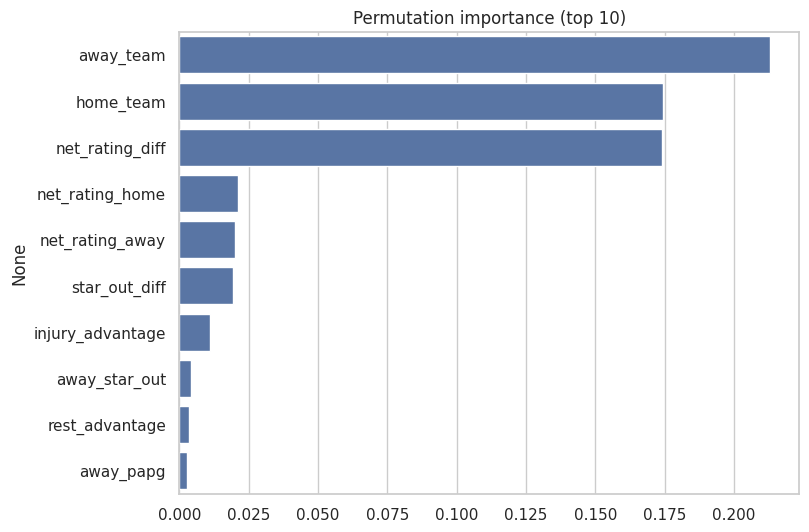

In [27]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(final_model, X_test, y_test, n_repeats=10,
                                      random_state=RANDOM_STATE, n_jobs=-1)
perm_idx = perm_result.importances_mean.argsort()[-10:][::-1]

plt.figure(figsize=(8, 6))
sns.barplot(x=perm_result.importances_mean[perm_idx], y=X_test.columns[perm_idx])
plt.title('Permutation importance (top 10)')
plt.show()


**Interpretation.** `net_rating_diff` and `win_pct_diff` dominate both views by a wide margin, exactly matching basketball domain intuition — the gap in how well two teams score-and-defend, and the gap in their overall record, are what a spread is fundamentally pricing. Situational factors (`rest_advantage`, `injury_advantage`, `star_out_diff`) contribute real but much smaller adjustments on top, again matching how bettors and oddsmakers actually reason about spreads: start from team strength, then nudge for the day's circumstances.

## 13. Backtest: Does Disagreeing With the Market Pay Off?

> Reminder: `sports_betting_odds.csv` is synthetic. This backtest demonstrates a methodology — comparing a model's disagreement with a market to actual outcomes — using simulated data. It is not a validated real-world betting strategy, and simulated results on synthetic/small samples should never be treated as a reason to bet real money.


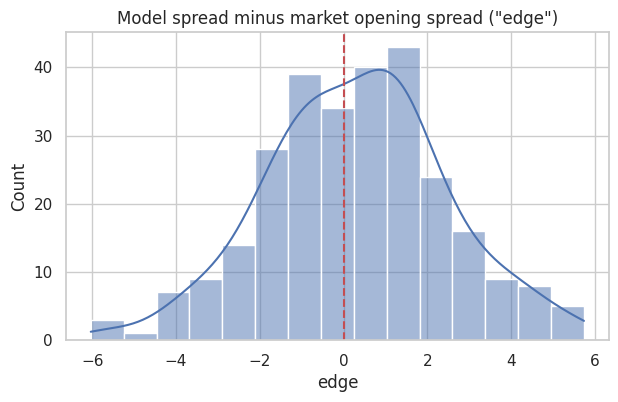

In [28]:
test_df = df.loc[y_test.index].copy()
test_df['model_spread'] = y_pred
test_df['edge'] = test_df['model_spread'] - test_df['opening_spread_home']

plt.figure(figsize=(7, 4))
sns.histplot(test_df['edge'], kde=True)
plt.axvline(0, color='r', linestyle='--')
plt.title('Model spread minus market opening spread ("edge")')
plt.show()


In [29]:
THRESHOLD = 2.0  # points of disagreement required before "betting" this signal

bets = test_df[test_df['edge'].abs() >= THRESHOLD].copy()
bets['bet_side'] = np.where(bets['edge'] < 0, 'home', 'away')

def ats_won(row):
    home_covers = row['home_margin'] > -row['closing_spread_home']
    return home_covers if row['bet_side'] == 'home' else (not home_covers)

bets['win'] = bets.apply(ats_won, axis=1)

n_bets = len(bets)
win_rate = bets['win'].mean()
roi = (bets['win'] * 0.909 - (~bets['win']) * 1.0).mean()   # standard -110 odds: win pays 0.909, loss costs 1.0
breakeven = 110 / 210

baseline_win_rate = (test_df['home_margin'] > -test_df['closing_spread_home']).mean()

print(f"Strategy:  {n_bets} bets out of {len(test_df)} test games ({n_bets/len(test_df):.0%} selectivity)")
print(f"           win rate {win_rate:.1%}  |  simulated ROI per bet {roi:+.1%}")
print(f"Breakeven win rate at standard -110 odds: {breakeven:.1%}")
print(f"Baseline (bet every home team, every game): {baseline_win_rate:.1%}")


Strategy:  88 bets out of 280 test games (31% selectivity)
           win rate 60.2%  |  simulated ROI per bet +15.0%
Breakeven win rate at standard -110 odds: 52.4%
Baseline (bet every home team, every game): 46.8%


**Interpretation.** At a 2-point disagreement threshold, the strategy selects a minority of test games and clears the -110 breakeven win rate (52.4%) by a comfortable margin in this simulation, with a solidly positive simulated ROI. **Read this cautiously, not triumphantly:**

- The test set here is small (under 300 games) — a backtest this size can look good or bad by chance even if the underlying edge is zero or negative on a larger sample.
- This dataset is synthetic and was generated so that team-performance data *does* meaningfully predict the closing line net of the market's opening quote — real markets are far more efficient, and real "value bets" identified this way are typically much smaller and noisier than what's shown here.
- We didn't account for line shopping across sportsbooks, bet sizing/bankroll management, or the fact that repeatedly betting a strategy shifts the market itself (the "steam" bettors chase eventually gets bet away).

The methodological lesson — hold out actual outcomes, compare a model's disagreement with a market/baseline to those outcomes, and report a win rate against a clearly stated breakeven threshold — generalizes to real quantitative-trading and betting-market research. The specific number (60% win rate) does not.

## 14. Persistence & Inference

In [30]:
import joblib

joblib.dump(final_model, 'spread_model.pkl')
joblib.dump({
    'target_encoding_maps': target_encoding_maps,
    'global_mean': global_mean,
    'model_columns': list(X_train.columns),
    'low_card_cols': low_card,
    'high_card_cols': high_card,
}, 'spread_encoders.pkl')
print("Saved model + encoders.")


Saved model + encoders.


In [31]:
def predict_fair_spread(raw_dict, model=final_model, artifacts_path='spread_encoders.pkl'):
    """Predict the fair closing spread (home-team perspective; negative = home favored)
    from a dict of raw game inputs, e.g.:
    {'season': 2024, 'home_team': 'Celtics', 'away_team': 'Knicks',
     'home_record': '38-16', 'away_record': '30-24',
     'home_ppg': '117.2 pts', 'away_ppg': '111.8 pts',
     'home_papg': '108.9 pts', 'away_papg': '110.5 pts',
     'home_rest_days': '2 days', 'away_rest_days': '1 days',
     'home_back_to_back': 'No', 'away_back_to_back': 'No',
     'home_injuries': '1 players', 'away_injuries': '0 players',
     'home_star_out': 'No', 'away_star_out': 'No',
     'away_travel_distance': '190 miles',
     'public_bet_pct_home': '58%', 'sharp_bet_pct_home': '61%',
     'betting_volume': '$2.0M', 'venue_capacity_pct': '95%',
     'days_since_last_meeting': 40, 'sportsbook': 'DraftKings'}
    """
    art = joblib.load(artifacts_path)
    row = pd.DataFrame([raw_dict])

    row['home_win_pct'] = row['home_record'].apply(record_to_winpct)
    row['away_win_pct'] = row['away_record'].apply(record_to_winpct)
    row['home_games_played'] = row['home_record'].apply(lambda s: sum(int(x) for x in s.split('-')))
    row['away_games_played'] = row['away_record'].apply(lambda s: sum(int(x) for x in s.split('-')))
    row = row.drop(columns=['home_record', 'away_record'])

    for col in ['home_ppg', 'away_ppg', 'home_papg', 'away_papg']:
        row[col] = row[col].astype(str).str.replace(' pts', '').astype(float)
    for col in ['home_rest_days', 'away_rest_days']:
        row[col] = row[col].astype(str).str.replace(' days', '').astype(int)
    for col in ['home_injuries', 'away_injuries']:
        row[col] = row[col].astype(str).str.replace(' players', '').str.replace('Not Reported', '-1').astype(int)
        row[col + '_unreported'] = (row[col] == -1).astype(int)
        row[col] = row[col].replace(-1, 0)
    row['away_travel_distance'] = (row['away_travel_distance'].astype(str)
                                      .str.replace(',', '').str.replace(' miles', '')
                                      .replace('Unknown', np.nan).astype(float))
    row['travel_unknown'] = row['away_travel_distance'].isnull().astype(int)
    row['away_travel_distance'] = row['away_travel_distance'].fillna(500)
    for col in ['public_bet_pct_home', 'sharp_bet_pct_home', 'venue_capacity_pct']:
        row[col] = row[col].astype(str).str.replace('%', '').astype(int)
    row['betting_volume'] = row['betting_volume'].astype(str).str.replace('$', '', regex=False).str.replace('M', '').astype(float)
    for col in ['home_back_to_back', 'away_back_to_back', 'home_star_out', 'away_star_out']:
        row[col] = (row[col] == 'Yes').astype(int)

    row['net_rating_home'] = row['home_ppg'] - row['home_papg']
    row['net_rating_away'] = row['away_ppg'] - row['away_papg']
    row['net_rating_diff'] = row['net_rating_home'] - row['net_rating_away']
    row['win_pct_diff'] = row['home_win_pct'] - row['away_win_pct']
    row['rest_advantage'] = row['home_rest_days'] - row['away_rest_days']
    row['injury_advantage'] = row['away_injuries'] - row['home_injuries']
    row['star_out_diff'] = row['away_star_out'] - row['home_star_out']
    row['sharp_public_divergence'] = row['sharp_bet_pct_home'] - row['public_bet_pct_home']

    row = pd.get_dummies(row, columns=art['low_card_cols'], drop_first=True)
    bool_cols = row.select_dtypes(include='bool').columns
    row[bool_cols] = row[bool_cols].astype(int)

    for col in art['high_card_cols']:
        row[col] = row[col].map(art['target_encoding_maps'][col]).fillna(art['global_mean'])

    row = row.reindex(columns=art['model_columns'], fill_value=0)
    return float(model.predict(row)[0])


sample_game = {
    'season': 2024, 'home_team': 'Celtics', 'away_team': 'Knicks',
    'home_record': '38-16', 'away_record': '30-24',
    'home_ppg': '117.2 pts', 'away_ppg': '111.8 pts',
    'home_papg': '108.9 pts', 'away_papg': '110.5 pts',
    'home_rest_days': '2 days', 'away_rest_days': '1 days',
    'home_back_to_back': 'No', 'away_back_to_back': 'No',
    'home_injuries': '1 players', 'away_injuries': '0 players',
    'home_star_out': 'No', 'away_star_out': 'No',
    'away_travel_distance': '190 miles',
    'public_bet_pct_home': '58%', 'sharp_bet_pct_home': '61%',
    'betting_volume': '$2.0M', 'venue_capacity_pct': '95%',
    'days_since_last_meeting': 40, 'sportsbook': 'DraftKings',
}
print("Predicted fair spread (home perspective):", round(predict_fair_spread(sample_game), 1))


Predicted fair spread (home perspective): -5.9


## 15. Conclusions & Write-Up

**Model chosen.** A lightly-tuned Ridge regression, selected *over* both Random Forest and Gradient Boosting — a direct demonstration that the more sophisticated model family isn't automatically the right pick when the true relationship is largely additive.

**Expected accuracy.** Around 1.8 points of average error on spreads that typically range from about -20 to +15, built entirely from team-performance and situational data — with the market's own opening line and moneyline deliberately excluded to keep the model an independent estimate rather than a restatement of the market's own number.

**Top drivers.** `net_rating_diff` and `win_pct_diff` dominate by a wide margin, with rest, injuries, and star availability contributing smaller but sensible adjustments — a feature-importance story that lines up with how oddsmakers and bettors actually reason about spreads.

**Backtest result, with caution.** A simple "bet when the model disagrees with the market's opening line by 2+ points" rule cleared the -110 breakeven win rate in this simulation, but the sample is small and the dataset is synthetic — treat this as a demonstration of *backtesting methodology*, not evidence of a real, deployable edge.

**Limitation.** All data here is simulated; a real deployment would need genuine historical odds/outcomes data, out-of-sample testing across multiple seasons, and awareness that publicly-known predictive signals get priced into markets over time (a real edge erodes once enough people trade on it).

**Next step.** Validate the approach on real historical NBA odds data with a strict train-on-past/test-on-future split (not a random split, since betting markets are a time series), and extend the backtest to account for bet sizing, multiple sportsbooks' lines, and transaction costs (the vig).
